# CSE 445 — Assignment 1 — Notebook 2: YOLOv10 Training, Evaluation & Error Analysis
# Group: J
Dataset: Dental X-ray Object Detection Dataset   
Source: https://data.mendeley.com/datasets/wxv6h9p39g/1

In [2]:
import os, shutil, zipfile, yaml
from pathlib import Path

DETECTION_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        DETECTION_ROOT = root
        break
print("Detected shared dataset root:", DETECTION_ROOT)

WORK_DIR = Path('/kaggle/working/dental_final')

for s in ['train', 'val', 'test']:
    img_out = WORK_DIR / s / 'images'
    lbl_out = WORK_DIR / s / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)

    zip_path = Path(DETECTION_ROOT) / f'{s}_images.zip'
    extracted_dir = Path(DETECTION_ROOT) / f'{s}_images'

    if zip_path.exists():
        print(f"{s}: found zip, extracting...")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(img_out)
    elif extracted_dir.exists():
        print(f"{s}: zip already auto-extracted by Kaggle, copying folder...")
        for f in extracted_dir.glob('*.jpg'):
            shutil.copy2(f, img_out / f.name)
    else:
        print(f"{s}: NEITHER zip nor extracted folder found — check the listing above for the real name/location")
        continue

    shutil.copytree(Path(DETECTION_ROOT) / s / 'labels', lbl_out, dirs_exist_ok=True)

    n_img = len(list(img_out.glob('*.jpg')))
    n_lbl = len(list(lbl_out.glob('*.txt')))
    print(f"{s}: {n_img} images, {n_lbl} labels\n")

with open(Path(DETECTION_ROOT) / 'data.yaml') as f:
    src_yaml = yaml.safe_load(f)

final_yaml = {
    'train': str(WORK_DIR / 'train' / 'images'),
    'val': str(WORK_DIR / 'val' / 'images'),
    'test': str(WORK_DIR / 'test' / 'images'),
    'nc': src_yaml['nc'],
    'names': src_yaml['names'],
}
with open(WORK_DIR / 'data.yaml', 'w') as f:
    yaml.dump(final_yaml, f)

print("data.yaml ready at:", WORK_DIR / 'data.yaml')

Detected shared dataset root: /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final
train: zip already auto-extracted by Kaggle, copying folder...
train: 7998 images, 7998 labels

val: zip already auto-extracted by Kaggle, copying folder...
val: 993 images, 993 labels

test: zip already auto-extracted by Kaggle, copying folder...
test: 1009 images, 1009 labels

data.yaml ready at: /kaggle/working/dental_final/data.yaml


# CONFIG

In [3]:
CONFIG = {
    'model_variant': 'yolov10m.pt',
    'model_size_justification': (
        "Dataset has 10,000 images (8k-20k bucket -> 'm or l' per guidance table). "
        "'m' chosen over 'l' for faster, timeout-safe training given the 2-day deadline, "
        "and to keep model capacity identical across v10/v12/v26 for a fair comparison."
    ),
    'epochs': 50,                  # mandated minimum for YOLO
    'imgsz': 640,                  # dataset's confirmed native resolution
    'batch': 16,                   # assignment's own stated safe value for T4 @ 640
    'optimizer': 'SGD',
    'lr0': 0.01,                   # matches what 'auto' would select at ~25,000 iterations
    'cos_lr': True,
    'warmup_epochs': 3,
    'patience': 50,                # == epochs, deliberately avoids conflicting with the
                                    # mandated minimum-50-epoch requirement (see reasoning above)

    # Augmentation - carried over from Notebook 1's measured/verified config
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.4,
    'fliplr': 0.5,
    'flipud': 0.0,
    'degrees': 10,
    'translate': 0.1,
    'scale': 0.3,
    'mosaic': 1.0,
    'close_mosaic': 10,
    'overlap_mask': True,
    'copy_paste': 0.0,

    # Inference / evaluation
    'iou': 0.6,   # lowered from default 0.7 per dense-scene guidance; moderate choice given
                  # our EDA also found legitimate close-together (non-duplicate) findings -
                  # to be checked specifically in error analysis
    'conf': 0.25,
}

print("YOLOv10 CONFIG set:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

YOLOv10 CONFIG set:
  model_variant: yolov10m.pt
  model_size_justification: Dataset has 10,000 images (8k-20k bucket -> 'm or l' per guidance table). 'm' chosen over 'l' for faster, timeout-safe training given the 2-day deadline, and to keep model capacity identical across v10/v12/v26 for a fair comparison.
  epochs: 50
  imgsz: 640
  batch: 16
  optimizer: SGD
  lr0: 0.01
  cos_lr: True
  warmup_epochs: 3
  patience: 50
  hsv_h: 0.0
  hsv_s: 0.0
  hsv_v: 0.4
  fliplr: 0.5
  flipud: 0.0
  degrees: 10
  translate: 0.1
  scale: 0.3
  mosaic: 1.0
  close_mosaic: 10
  overlap_mask: True
  copy_paste: 0.0
  iou: 0.6
  conf: 0.25


In [4]:
!pip install ultralytics -q

import torch, os
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

DETECTION_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        DETECTION_ROOT = root
        break
print("Detected shared dataset root:", DETECTION_ROOT)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.1 MB/s eta 0:00:0000:010:01
GPU available: True
GPU name: Tesla T4
Detected shared dataset root: /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final


In [5]:
import os, shutil, zipfile, yaml
from pathlib import Path

DETECTION_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        DETECTION_ROOT = root
        break
print("Detected shared dataset root:", DETECTION_ROOT)

WORK_DIR = Path('/kaggle/working/dental_final')

for s in ['train', 'val', 'test']:
    img_out = WORK_DIR / s / 'images'
    lbl_out = WORK_DIR / s / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)

    zip_path = Path(DETECTION_ROOT) / f'{s}_images.zip'
    extracted_dir = Path(DETECTION_ROOT) / f'{s}_images'

    if zip_path.exists():
        print(f"{s}: found zip, extracting...")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(img_out)
    elif extracted_dir.exists():
        print(f"{s}: zip already auto-extracted by Kaggle, copying folder...")
        for f in extracted_dir.glob('*.jpg'):
            shutil.copy2(f, img_out / f.name)
    else:
        print(f"{s}: NEITHER zip nor extracted folder found — check the listing above for the real name/location")
        continue

    shutil.copytree(Path(DETECTION_ROOT) / s / 'labels', lbl_out, dirs_exist_ok=True)

    n_img = len(list(img_out.glob('*.jpg')))
    n_lbl = len(list(lbl_out.glob('*.txt')))
    print(f"{s}: {n_img} images, {n_lbl} labels\n")

with open(Path(DETECTION_ROOT) / 'data.yaml') as f:
    src_yaml = yaml.safe_load(f)

final_yaml = {
    'train': str(WORK_DIR / 'train' / 'images'),
    'val': str(WORK_DIR / 'val' / 'images'),
    'test': str(WORK_DIR / 'test' / 'images'),
    'nc': src_yaml['nc'],
    'names': src_yaml['names'],
}
with open(WORK_DIR / 'data.yaml', 'w') as f:
    yaml.dump(final_yaml, f)

print("data.yaml ready at:", WORK_DIR / 'data.yaml')

Detected shared dataset root: /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final
train: zip already auto-extracted by Kaggle, copying folder...
train: 7998 images, 7998 labels

val: zip already auto-extracted by Kaggle, copying folder...
val: 993 images, 993 labels

test: zip already auto-extracted by Kaggle, copying folder...
test: 1009 images, 1009 labels

data.yaml ready at: /kaggle/working/dental_final/data.yaml


# 1-epoch dry run

In [6]:
from ultralytics import YOLO
import time

model = YOLO(CONFIG['model_variant'])

start = time.time()
dry_run_results = model.train(
    data=str(WORK_DIR / 'data.yaml'),
    epochs=1,
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch'],
    optimizer=CONFIG['optimizer'],
    lr0=CONFIG['lr0'],
    cos_lr=CONFIG['cos_lr'],
    warmup_epochs=CONFIG['warmup_epochs'],
    hsv_h=CONFIG['hsv_h'], hsv_s=CONFIG['hsv_s'], hsv_v=CONFIG['hsv_v'],
    fliplr=CONFIG['fliplr'], flipud=CONFIG['flipud'], degrees=CONFIG['degrees'],
    translate=CONFIG['translate'], scale=CONFIG['scale'],
    mosaic=CONFIG['mosaic'], close_mosaic=CONFIG['close_mosaic'],
    overlap_mask=CONFIG['overlap_mask'], copy_paste=CONFIG['copy_paste'],
    project='/kaggle/working/yolov10m_dental',
    name='dry_run',
    exist_ok=True,
)
elapsed_min = (time.time() - start) / 60

print(f"\n1-epoch time: {elapsed_min:.1f} minutes")
print(f"Estimated total for 50 epochs: {elapsed_min * 50 / 60:.1f} hours")
print(f"Kaggle session budget: ~8 hours (leaving 1 hour buffer)")
print(f"Fits within budget: {elapsed_min * 50 / 60 < 8}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dental_final/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hs

#  Full training run

In [ ]:
model_full = YOLO(CONFIG['model_variant'])  

full_results = model_full.train(
    data=str(WORK_DIR / 'data.yaml'),
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch'],
    optimizer=CONFIG['optimizer'],
    lr0=CONFIG['lr0'],
    cos_lr=CONFIG['cos_lr'],
    warmup_epochs=CONFIG['warmup_epochs'],
    patience=CONFIG['patience'],
    hsv_h=CONFIG['hsv_h'], hsv_s=CONFIG['hsv_s'], hsv_v=CONFIG['hsv_v'],
    fliplr=CONFIG['fliplr'], flipud=CONFIG['flipud'], degrees=CONFIG['degrees'],
    translate=CONFIG['translate'], scale=CONFIG['scale'],
    mosaic=CONFIG['mosaic'], close_mosaic=CONFIG['close_mosaic'],
    overlap_mask=CONFIG['overlap_mask'], copy_paste=CONFIG['copy_paste'],
    project='/kaggle/working/yolov10m_dental',
    name='full_run',
    exist_ok=True,
)

In [1]:
import os
from pathlib import Path

print("=== Checking /kaggle/working (current live session files) ===")
for root, dirs, files in os.walk('/kaggle/working'):
    if 'best.pt' in files:
        print(" FOUND in working dir:", os.path.join(root, 'best.pt'))

print("\n=== Checking /kaggle/input (attached datasets) ===")
if os.path.exists('/kaggle/input'):
    for item in os.listdir('/kaggle/input'):
        print(" attached:", item)
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'best.pt' in files:
            print(" FOUND in input:", os.path.join(root, 'best.pt'))
else:
    print(" /kaggle/input doesn't exist or isn't accessible")

=== Checking /kaggle/working (current live session files) ===

=== Checking /kaggle/input (attached datasets) ===
 attached: datasets


In [2]:
import os

print("=== Everything under /kaggle/input (your attached datasets) ===")
for item in os.listdir('/kaggle/input'):
    print(" ", item)

print("\n=== Looking specifically for best.pt anywhere in /kaggle/input ===")
for root, dirs, files in os.walk('/kaggle/input'):
    if 'best.pt' in files:
        print(" FOUND:", os.path.join(root, 'best.pt'))

=== Everything under /kaggle/input (your attached datasets) ===
  datasets

=== Looking specifically for best.pt anywhere in /kaggle/input ===
 FOUND: /kaggle/input/datasets/kanizmithila/yolov10-checkpoint/yolov10m_dental/dry_run/weights/best.pt
 FOUND: /kaggle/input/datasets/kanizmithila/yolov10-checkpoint/yolov10m_dental/full_run/weights/best.pt


In [3]:
import os
from pathlib import Path

DETECTION_ROOT = None
FULL_RUN_CKPT = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        DETECTION_ROOT = root
    if 'best.pt' in files and 'full_run' in root:   
        FULL_RUN_CKPT = os.path.join(root, 'best.pt')

print("Team dataset (data.yaml) found at:", DETECTION_ROOT)
print("Full-run checkpoint found at:", FULL_RUN_CKPT)

assert DETECTION_ROOT is not None, "Team dataset not attached — add it as an Input"
assert FULL_RUN_CKPT is not None, "Full-run checkpoint not found — check the checkpoint dataset is attached"
print("\nBoth confirmed — safe to proceed.")

Team dataset (data.yaml) found at: /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final
Full-run checkpoint found at: /kaggle/input/datasets/kanizmithila/yolov10-checkpoint/yolov10m_dental/full_run/weights/best.pt

Both confirmed — safe to proceed.


In [5]:
from ultralytics import YOLO

print("Loading checkpoint from:", FULL_RUN_CKPT)
model = YOLO(FULL_RUN_CKPT)

test_results = model.val(
    data=str(WORK_DIR / 'data.yaml'),
    split='test',
    imgsz=640, batch=16,
    conf=0.25, iou=0.6,
)

print("\n=== Overall test-split metrics ===")
p, r = test_results.box.mp, test_results.box.mr
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
print(f"Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")
print(f"mAP@50: {test_results.box.map50:.3f} | mAP@50-95: {test_results.box.map:.3f}")

inference_ms = test_results.speed['inference']
print(f"Inference speed: {inference_ms:.2f} ms/image -> FPS: {1000/inference_ms:.1f}")

print("\n=== Per-class metrics ===")
for i, name in enumerate(CLASS_NAMES):
    p_c, r_c = test_results.box.p[i], test_results.box.r[i]
    f1_c = 2 * p_c * r_c / (p_c + r_c) if (p_c + r_c) > 0 else 0
    print(f"{name:12s} P={p_c:.3f} R={r_c:.3f} F1={f1_c:.3f} mAP50={test_results.box.ap50[i]:.3f} mAP50-95={test_results.box.ap[i]:.3f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading checkpoint from: /kaggle/input/datasets/kanizmithila/yolov10-checkpoint/yolov10m_dental/full_run/weights/best.pt
Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv10m summary (fused): 136 layers, 15,315,484 parameters, 0 gradients, 58.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1150.1±334.1 MB/s, size: 36.4 KB)
val: Scanning /kaggle/working/dental_final/test/labels... 1009 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1009/1009 1.2Kit/s 0.8s0s
val: New cache created: /kaggle/working/dental_final/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━

In [6]:
for s in ['train', 'val', 'test']:
    img_dir = WORK_DIR / s / 'images'
    lbl_dir = WORK_DIR / s / 'labels'
    n_img = len(list(img_dir.glob('*.jpg')))
    n_lbl = len(list(lbl_dir.glob('*.txt')))
    print(f"{s}: {n_img} images actually present right now, {n_lbl} labels actually present right now")

train: 7998 images actually present right now, 7998 labels actually present right now
val: 993 images actually present right now, 993 labels actually present right now
test: 1009 images actually present right now, 1009 labels actually present right now


# **Run inference on the full test set and classify every box:**

In [7]:
import numpy as np

test_img_dir = WORK_DIR / 'test' / 'images'
test_lbl_dir = WORK_DIR / 'test' / 'labels'

def load_gt_boxes(label_path):
    if not label_path.exists() or label_path.stat().st_size == 0:
        return np.zeros((0, 5))
    lines = label_path.read_text().strip().split('\n')
    boxes = []
    for line in lines:
        parts = line.split()
        boxes.append([int(parts[0])] + [float(x) for x in parts[1:5]])
    return np.array(boxes)

def iou_xywh(box1, box2):
    def to_xyxy(b):
        x, y, w, h = b
        return [x - w/2, y - h/2, x + w/2, y + h/2]
    b1, b2 = to_xyxy(box1), to_xyxy(box2)
    xi1, yi1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    xi2, yi2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

false_negatives, false_positives, misclassifications = [], [], []
IOU_THRESH = 0.5

results = model.predict(source=str(test_img_dir), conf=0.25, iou=0.6, imgsz=640, verbose=False)

for r in results:
    img_id = Path(r.path).stem
    gt = load_gt_boxes(test_lbl_dir / f'{img_id}.txt')
    preds = r.boxes.xywhn.cpu().numpy() if len(r.boxes) else np.zeros((0, 4))
    pred_cls = r.boxes.cls.cpu().numpy() if len(r.boxes) else np.zeros((0,))
    pred_conf = r.boxes.conf.cpu().numpy() if len(r.boxes) else np.zeros((0,))

    matched_gt, matched_pred = set(), set()

    for gi, g in enumerate(gt):
        best_iou, best_pi = 0, -1
        for pi, p in enumerate(preds):
            if pi in matched_pred:
                continue
            iou = iou_xywh(g[1:], p)
            if iou > best_iou:
                best_iou, best_pi = iou, pi
        if best_iou >= IOU_THRESH:
            matched_gt.add(gi)
            matched_pred.add(best_pi)
            if int(pred_cls[best_pi]) != int(g[0]):
                misclassifications.append({'image_id': img_id, 'true_class': CLASS_NAMES[int(g[0])],
                                            'pred_class': CLASS_NAMES[int(pred_cls[best_pi])], 'iou': best_iou})

    for gi, g in enumerate(gt):
        if gi not in matched_gt:
            false_negatives.append({'image_id': img_id, 'true_class': CLASS_NAMES[int(g[0])], 'box': g[1:]})

    for pi, p in enumerate(preds):
        if pi not in matched_pred:
            false_positives.append({'image_id': img_id, 'pred_class': CLASS_NAMES[int(pred_cls[pi])],
                                      'conf': pred_conf[pi], 'box': p})

print(f"Total false negatives: {len(false_negatives)}")
print(f"Total false positives: {len(false_positives)}")
print(f"Total misclassifications (matched box, wrong class): {len(misclassifications)}")

print("\nFalse negatives by class:")
import pandas as pd
print(pd.DataFrame(false_negatives)['true_class'].value_counts())
print("\nFalse positives by class:")
print(pd.DataFrame(false_positives)['pred_class'].value_counts())

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Total false negatives: 1153
Total false positives: 938
Total misclassifications (matched box, wrong class): 24

False negatives by class:
true_class
Damage       558
Cavities     337
Infection    228
Wisdom        30
Name: count, dtype: int64

False positives by class:
pred_class
Damage       482
Cavities     259
Infection    132
Wisdom        65
Name: count, dtype: int64


In [8]:
false_negatives, false_positives, misclassifications = [], [], []

for r in results:
    img_id = Path(r.path).stem
    gt = load_gt_boxes(test_lbl_dir / f'{img_id}.txt')
    preds = r.boxes.xywhn.cpu().numpy() if len(r.boxes) else np.zeros((0, 4))
    pred_cls = r.boxes.cls.cpu().numpy() if len(r.boxes) else np.zeros((0,))
    pred_conf = r.boxes.conf.cpu().numpy() if len(r.boxes) else np.zeros((0,))

    matched_gt, matched_pred = set(), set()

    for gi, g in enumerate(gt):
        best_iou, best_pi = 0, -1
        for pi, p in enumerate(preds):
            if pi in matched_pred:
                continue
            iou = iou_xywh(g[1:], p)
            if iou > best_iou:
                best_iou, best_pi = iou, pi
        if best_iou >= IOU_THRESH:
            matched_gt.add(gi); matched_pred.add(best_pi)
            if int(pred_cls[best_pi]) != int(g[0]):
                misclassifications.append({'image_id': img_id, 'true_class': CLASS_NAMES[int(g[0])],
                                            'pred_class': CLASS_NAMES[int(pred_cls[best_pi])],
                                            'iou': best_iou, 'pred_box': preds[best_pi], 'true_box': g[1:]})

    for gi, g in enumerate(gt):
        if gi not in matched_gt:
            false_negatives.append({'image_id': img_id, 'true_class': CLASS_NAMES[int(g[0])], 'box': g[1:]})
    for pi, p in enumerate(preds):
        if pi not in matched_pred:
            false_positives.append({'image_id': img_id, 'pred_class': CLASS_NAMES[int(pred_cls[pi])],
                                      'conf': pred_conf[pi], 'box': p})

print("Recount check -> FN:", len(false_negatives), "FP:", len(false_positives), "Misclass:", len(misclassifications))

Recount check -> FN: 1153 FP: 938 Misclass: 24


# FN, FP, and misclassification examples together:

=== False Negatives ===


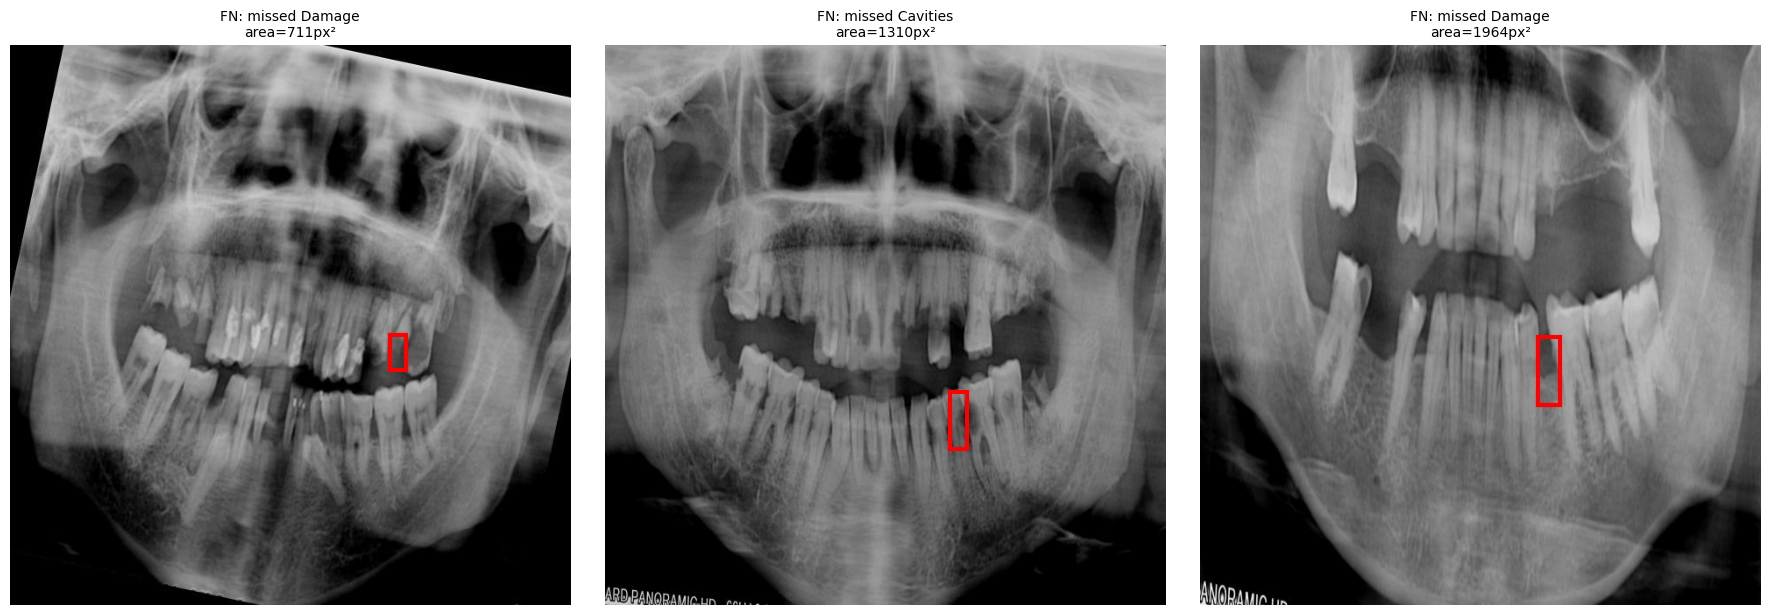

=== False Positives ===


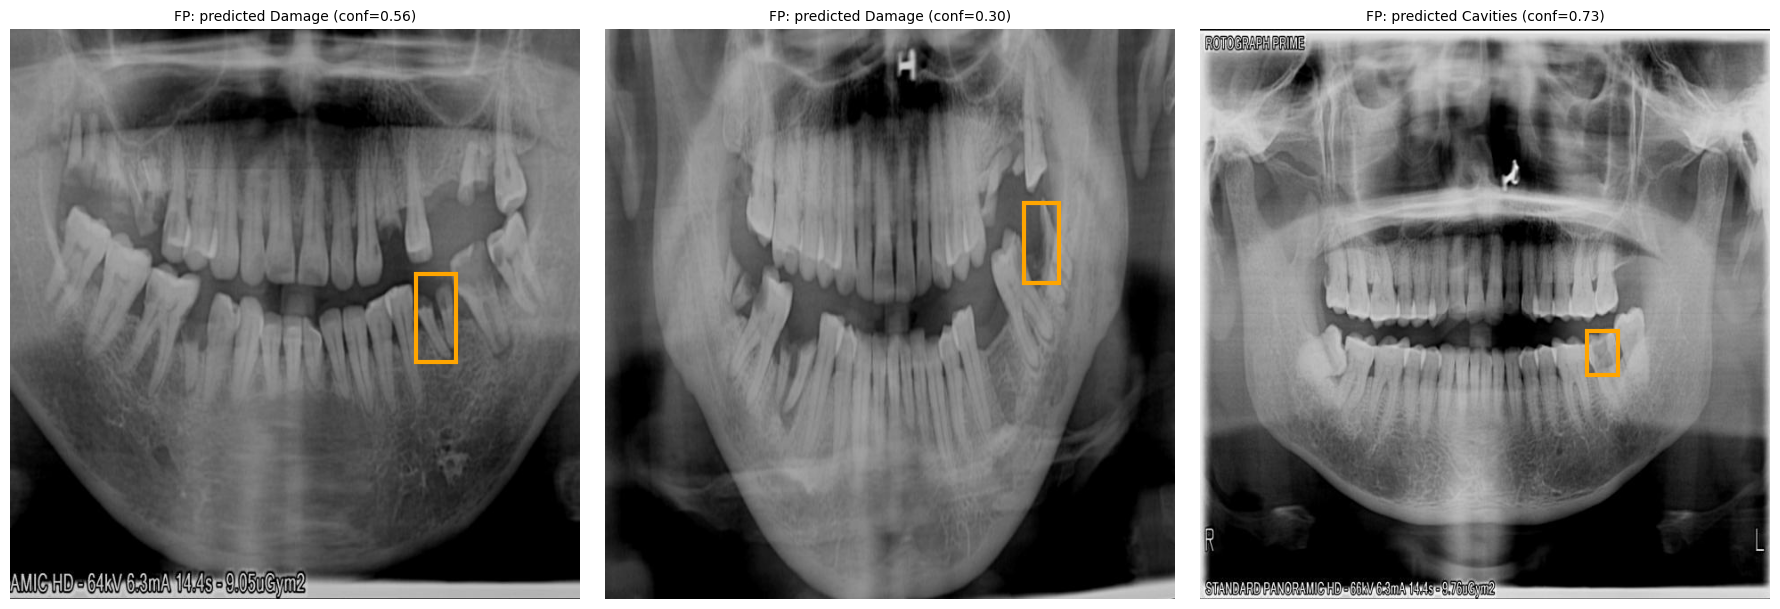

=== Misclassifications ===


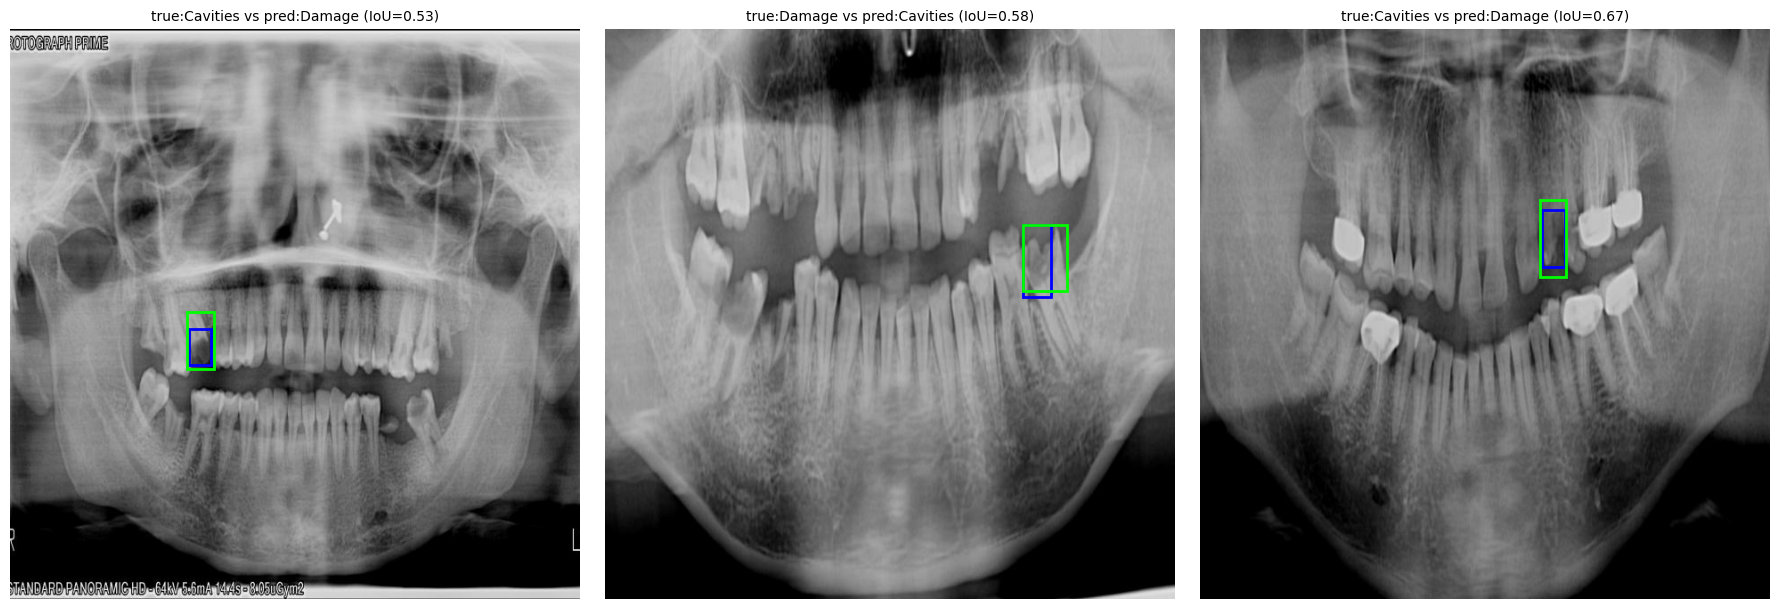

In [9]:
import random, cv2
import matplotlib.pyplot as plt

def show_examples(examples, kind, n=3, seed=1):
    random.seed(seed)
    sampled = random.sample(examples, min(n, len(examples)))
    fig, axes = plt.subplots(1, len(sampled), figsize=(6*len(sampled), 6))
    if len(sampled) == 1:
        axes = [axes]
    for ax, ex in zip(axes, sampled):
        img = cv2.cvtColor(cv2.imread(str(test_img_dir / f"{ex['image_id']}.jpg")), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)

        if kind == 'FN':
            x_c, y_c, bw, bh = ex['box']
            x1, y1 = (x_c-bw/2)*w, (y_c-bh/2)*h
            ax.add_patch(plt.Rectangle((x1,y1), bw*w, bh*h, fill=False, color='red', linewidth=3))
            ax.set_title(f"FN: missed {ex['true_class']}\narea={bw*w*bh*h:.0f}px²", fontsize=10)
        elif kind == 'FP':
            x_c, y_c, bw, bh = ex['box']
            x1, y1 = (x_c-bw/2)*w, (y_c-bh/2)*h
            ax.add_patch(plt.Rectangle((x1,y1), bw*w, bh*h, fill=False, color='orange', linewidth=3))
            ax.set_title(f"FP: predicted {ex['pred_class']} (conf={ex['conf']:.2f})", fontsize=10)
        elif kind == 'MIS':
            for box, color, label in [(ex['true_box'], 'blue', f"true:{ex['true_class']}"),
                                       (ex['pred_box'], 'lime', f"pred:{ex['pred_class']}")]:
                x_c, y_c, bw, bh = box
                x1, y1 = (x_c-bw/2)*w, (y_c-bh/2)*h
                ax.add_patch(plt.Rectangle((x1,y1), bw*w, bh*h, fill=False, color=color, linewidth=2))
            ax.set_title(f"true:{ex['true_class']} vs pred:{ex['pred_class']} (IoU={ex['iou']:.2f})", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

fn_weak = [e for e in false_negatives if e['true_class'] != 'Wisdom']
fp_weak = [e for e in false_positives if e['pred_class'] != 'Wisdom']

print("=== False Negatives ===")
show_examples(fn_weak, 'FN', n=3)
print("=== False Positives ===")
show_examples(fp_weak, 'FP', n=3)
print("=== Misclassifications ===")
show_examples(misclassifications, 'MIS', n=min(3, len(misclassifications)))

# Verifying with real numbers before writing the summary

In [10]:
mis_df = pd.DataFrame(misclassifications)
print("Confusion pairs across ALL 24 misclassifications:")
print(mis_df.groupby(['true_class', 'pred_class']).size().sort_values(ascending=False))

Confusion pairs across ALL 24 misclassifications:
true_class  pred_class
Damage      Cavities      13
Cavities    Damage         5
Infection   Damage         3
Damage      Wisdom         2
            Infection      1
dtype: int64


In [11]:
import numpy as np

all_gt_areas = []
for lbl_file in test_lbl_dir.glob('*.txt'):
    gt = load_gt_boxes(lbl_file)
    for row in gt:
        _, x, y, bw, bh = row
        all_gt_areas.append(bw * 640 * bh * 640)

fn_areas = [(lambda b: b[2]*640*b[3]*640)(e['box']) for e in false_negatives]

print(f"Median area — ALL test ground-truth boxes: {np.median(all_gt_areas):.0f} px²")
print(f"Median area — FALSE NEGATIVE boxes only:   {np.median(fn_areas):.0f} px²")
print(f"FN boxes are smaller by: {(1 - np.median(fn_areas)/np.median(all_gt_areas))*100:.1f}%")

Median area — ALL test ground-truth boxes: 2432 px²
Median area — FALSE NEGATIVE boxes only:   2100 px²
FN boxes are smaller by: 13.6%


# Finalized failure-pattern summary — 

The dominant failure mode for YOLOv10 on this dataset is a recall problem rather than a classification problem. Misclassifications account for fewer than 1% of all instances (24 out of approximately 2,520), meaning that when the model successfully detects a real finding, it almost always predicts the correct disease. Per-instance false-negative rates are highest for Infection (60.2%) and for both Cavities and Damage (approximately 50% each), whereas Wisdom, which is visually larger and structurally more distinct, is detected much more reliably with only an 8.8% miss rate.

Among the few misclassifications that occur, 75% (18 out of 24) involve confusion between the Cavities and Damage classes in both directions. This suggests that these two classes share visual characteristics that the model finds difficult to distinguish, while Infection and Wisdom are rarely confused with any other class. Additionally, false-negative bounding boxes are only about 13.6% smaller than the dataset average, indicating that object size alone does not explain the majority of missed detections. Instead, visual subtlety and the annotation inconsistencies observed in Notebook 1—such as identical images being labeled with different diseases—are more likely responsible for these errors than object scale.

# checkpoint path

In [13]:
print("=== Notebook 2 (YOLOv10) — Final Checkpoint ===")
print(f"Best checkpoint: {FULL_RUN_CKPT}")
print(f"Packaged as Kaggle dataset: kanizmithila/yolov10-checkpoint")

precision_final = test_results.box.mp
recall_final = test_results.box.mr
f1_final = 2 * precision_final * recall_final / (precision_final + recall_final) if (precision_final + recall_final) > 0 else 0

print(f"\nFinal test-split metrics:")
print(f"  Precision: {precision_final:.3f} | Recall: {recall_final:.3f} | F1: {f1_final:.3f}")
print(f"  mAP@50: {test_results.box.map50:.3f} | mAP@50-95: {test_results.box.map:.3f}")
print(f"  Inference speed: {1000/inference_ms:.1f} FPS")

=== Notebook 2 (YOLOv10) — Final Checkpoint ===
Best checkpoint: /kaggle/input/datasets/kanizmithila/yolov10-checkpoint/yolov10m_dental/full_run/weights/best.pt
Packaged as Kaggle dataset: kanizmithila/yolov10-checkpoint

Final test-split metrics:
  Precision: 0.621 | Recall: 0.579 | F1: 0.599
  mAP@50: 0.477 | mAP@50-95: 0.221
  Inference speed: 52.2 FPS
